In [2]:
# =============================================================================
# 6 : RANDOM FOREST CLASSIFIER — Gold Price Direction Prediction
# =============================================================================
# Target: ทำนาย target_direction (-1 = DOWN, 0 = SIDE, +1 = UP)
# Data  : X_train_scaled, X_val_scaled, X_test_scaled (ผ่าน split/scale แล้ว)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# ── Color palette (financial theme)
CLR = {"UP": "#2ecc71", "DOWN": "#e74c3c", "SIDE": "#f39c12",
       "bg": "#0f1117", "card": "#1a1f2e", "text": "#ecf0f1"}

# =============================================================================
# 1 : LOAD DATA
# =============================================================================
print("=" * 65)
print("  1 : LOAD & VERIFY DATA")
print("=" * 65)

# ── โหลด Features
X_train = pd.read_csv("../../../data/processed/splits/X_train.csv",
                      parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv("../../../data/processed/splits/X_val.csv",
                      parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv("../../../data/processed/splits/X_test.csv",
                      parse_dates=["Date"], index_col="Date")

# ── โหลด Classification targets
y_train = pd.read_csv("../../../data/processed/splits/y_train_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv("../../../data/processed/splits/y_val_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv("../../../data/processed/splits/y_test_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()

# ── Verify shapes & time order
print(f"\n  X_train : {X_train.shape}  |  {X_train.index.min().date()} → {X_train.index.max().date()}")
print(f"  X_val   : {X_val.shape}   |  {X_val.index.min().date()} → {X_val.index.max().date()}")
print(f"  X_test  : {X_test.shape}  |  {X_test.index.min().date()} → {X_test.index.max().date()}")

assert X_train.isnull().sum().sum() == 0, "NaN in X_train!"
assert X_val.isnull().sum().sum()   == 0, "NaN in X_val!"
assert X_test.isnull().sum().sum()  == 0, "NaN in X_test!"
assert X_train.index.is_monotonic_increasing, "Train index not sorted!"
assert X_train.index.max() < X_val.index.min(), "Train/Val overlap!"
assert X_val.index.max()   < X_test.index.min(), "Val/Test overlap!"

print("\n  ✔ No NaN | ✔ Time-sorted | ✔ No overlap")

# =============================================================================
# 2 : TARGET DISTRIBUTION CHECK
# =============================================================================
print("\n" + "=" * 65)
print("  2 : TARGET DISTRIBUTION PER SPLIT")
print("=" * 65)

label_map = {-1: "DOWN", 0: "SIDE", 1: "UP"}
splits    = {"Train": y_train, "Val": y_val, "Test": y_test}

print(f"\n  {'Label':<8} {'Train':>10} {'Val':>10} {'Test':>10}")
print("  " + "-" * 40)
for lbl, name in label_map.items():
    row = {k: (v == lbl).mean() * 100 for k, v in splits.items()}
    print(f"  {name:<8} {row['Train']:>9.1f}% {row['Val']:>9.1f}% {row['Test']:>9.1f}%")

dominant = max((y_train.value_counts(normalize=True).max() * 100), 0)
if dominant > 60:
    print(f"\n  ⚠ Class Imbalance: dominant = {dominant:.1f}%  → ใช้ class_weight='balanced'")
else:
    print(f"\n  ✔ Class balance OK (max class = {dominant:.1f}%) → class_weight='balanced' ยังช่วยได้")

# =============================================================================
# 3 : TRAIN RANDOM FOREST CLASSIFIER
# =============================================================================
print("\n" + "=" * 65)
print("  3 : TRAIN RANDOM FOREST CLASSIFIER")
print("=" * 65)

# ── Parameter rationale:
# n_estimators=300 : ต้นไม้มากขึ้น → variance ลด, stable กว่า 100
# max_depth=8       : จำกัดความลึก → ลด overfitting บน noisy financial data
# min_samples_leaf=20: ใบต้องมี ≥20 sample → ป้องกัน memorize noise
# max_features='sqrt': feature subset per split (default for classifiers)
# class_weight='balanced': ชดเชย SIDE ที่มีมากกว่า UP/DOWN
# random_state=42   : reproducible

rf_clf = RandomForestClassifier(
    n_estimators   = 300,
    max_depth      = 8,
    min_samples_leaf = 20,
    min_samples_split = 40,
    max_features   = "sqrt",
    class_weight   = "balanced",
    random_state   = 42,
    n_jobs         = -1
)

print("\n  Training Random Forest Classifier...")
rf_clf.fit(X_train, y_train)
print("  ✔ Training complete")
print(f"\n  Parameters:")
print(f"    n_estimators    = 300  (stable ensemble)")
print(f"    max_depth       = 8   (prevent overfitting on noisy data)")
print(f"    min_samples_leaf= 20  (avoid memorizing outliers)")
print(f"    class_weight    = 'balanced'  (correct SIDE dominance)")

# =============================================================================
# 4 : VALIDATION EVALUATION
# =============================================================================
print("\n" + "=" * 65)
print("  4 : VALIDATION SET EVALUATION")
print("=" * 65)

y_val_pred  = rf_clf.predict(X_val)
y_val_proba = rf_clf.predict_proba(X_val)

def evaluate(y_true, y_pred, split_name=""):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    # Directional accuracy (UP vs DOWN only, exclude SIDE)
    mask = (y_true != 0) & (y_pred != 0)
    dir_acc = accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else np.nan
    # Hit ratio: fraction correctly predicted as UP or DOWN (excluding SIDE pred)
    non_side_pred = (y_pred != 0)
    hit_ratio = (y_true[non_side_pred] == y_pred[non_side_pred]).mean() if non_side_pred.sum() > 0 else np.nan
    return dict(acc=acc, prec=prec, rec=rec, f1=f1,
                dir_acc=dir_acc, hit_ratio=hit_ratio)

val_metrics = evaluate(y_val, y_val_pred, "Val")
print(f"\n  Accuracy           : {val_metrics['acc']:.4f}")
print(f"  Precision (macro)  : {val_metrics['prec']:.4f}")
print(f"  Recall    (macro)  : {val_metrics['rec']:.4f}")
print(f"  F1        (macro)  : {val_metrics['f1']:.4f}")
print(f"\n  ── Financial Metrics ──")
print(f"  Directional Accuracy (UP/DOWN only) : {val_metrics['dir_acc']:.4f}")
print(f"  Hit Ratio (non-SIDE predictions)    : {val_metrics['hit_ratio']:.4f}")

print("\n  Classification Report (Val):")
print(classification_report(y_val, y_val_pred,
      target_names=["DOWN(-1)", "SIDE(0)", "UP(+1)"],
      digits=4))

# =============================================================================
# 5 : TEST SET EVALUATION
# =============================================================================
print("\n" + "=" * 65)
print("  5 : TEST SET EVALUATION")
print("=" * 65)

y_test_pred = rf_clf.predict(X_test)
test_metrics = evaluate(y_test, y_test_pred, "Test")

print(f"\n  Accuracy           : {test_metrics['acc']:.4f}")
print(f"  Precision (macro)  : {test_metrics['prec']:.4f}")
print(f"  Recall    (macro)  : {test_metrics['rec']:.4f}")
print(f"  F1        (macro)  : {test_metrics['f1']:.4f}")
print(f"\n  ── Financial Metrics ──")
print(f"  Directional Accuracy (UP/DOWN only) : {test_metrics['dir_acc']:.4f}")
print(f"  Hit Ratio (non-SIDE predictions)    : {test_metrics['hit_ratio']:.4f}")

print("\n  Classification Report (Test):")
print(classification_report(y_test, y_test_pred,
      target_names=["DOWN(-1)", "SIDE(0)", "UP(+1)"],
      digits=4))

# ── Val vs Test comparison
print("\n  ── Val vs Test Comparison ──")
print(f"  {'Metric':<30} {'Val':>8} {'Test':>8} {'Gap':>8}")
print("  " + "-" * 56)
for k in ["acc", "prec", "rec", "f1", "dir_acc", "hit_ratio"]:
    gap = test_metrics[k] - val_metrics[k]
    flag = "⚠" if abs(gap) > 0.05 else " "
    print(f"  {k:<30} {val_metrics[k]:>8.4f} {test_metrics[k]:>8.4f} {gap:>+8.4f} {flag}")

# =============================================================================
# 6 : TRAIN METRICS (Overfitting check)
# =============================================================================
print("\n" + "=" * 65)
print("  6 : OVERFITTING CHECK (Train vs Val vs Test)")
print("=" * 65)

y_train_pred  = rf_clf.predict(X_train)
train_metrics = evaluate(y_train, y_train_pred, "Train")

print(f"\n  {'Metric':<20} {'Train':>8} {'Val':>8} {'Test':>8}")
print("  " + "-" * 44)
for k in ["acc", "f1", "dir_acc"]:
    print(f"  {k:<20} {train_metrics[k]:>8.4f} {val_metrics[k]:>8.4f} {test_metrics[k]:>8.4f}")

gap = train_metrics["acc"] - val_metrics["acc"]
if gap > 0.15:
    print(f"\n  ⚠ Overfitting detected: Train-Val acc gap = {gap:.4f}")
else:
    print(f"\n  ✔ Overfitting mild: Train-Val acc gap = {gap:.4f}")

# =============================================================================
# 7 : FEATURE IMPORTANCE
# =============================================================================
print("\n" + "=" * 65)
print("  7 : FEATURE IMPORTANCE (Top 20)")
print("=" * 65)

feat_imp = pd.Series(
    rf_clf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

top20 = feat_imp.head(20)
print(f"\n  {'Rank':<5} {'Feature':<35} {'Importance':>12}")
print("  " + "-" * 54)
for i, (feat, imp) in enumerate(top20.items(), 1):
    bar = "█" * int(imp * 500)
    print(f"  {i:<5} {feat:<35} {imp:>10.4f}  {bar}")

# =============================================================================
# 8 : REGIME ANALYSIS
# =============================================================================
print("\n" + "=" * 65)
print("  8 : REGIME ANALYSIS (High Vol vs Low Vol)")
print("=" * 65)

# ── Define volatility regime on test set
# ใช้ feature f_gold_vol_20d หรือ rolling std ของ y_test เป็น proxy
# (ถ้ามี feature นั้น ใช้เลย; ถ้าไม่มี ให้ใช้ rolling std ของ target)
vol_col_candidates = [c for c in X_test.columns if "vol" in c.lower() and "gold" in c.lower()]
if vol_col_candidates:
    vol_proxy = X_test[vol_col_candidates[0]]
    vol_label = vol_col_candidates[0]
else:
    # fallback: rolling std ของ y_test_reg ถ้าโหลดได้
    vol_proxy = pd.Series(np.random.rand(len(X_test)), index=X_test.index)
    vol_label = "simulated_vol"

vol_median     = vol_proxy.median()
high_vol_mask  = vol_proxy >= vol_median
low_vol_mask   = vol_proxy <  vol_median

def regime_report(mask, label):
    yt = y_test[mask]
    yp = pd.Series(y_test_pred, index=y_test.index)[mask]
    if len(yt) < 10:
        return
    acc    = accuracy_score(yt, yp)
    f1_m   = f1_score(yt, yp, average="macro", zero_division=0)
    dir_m  = (yt != 0) & (yp != 0)
    da     = accuracy_score(yt[dir_m], yp[dir_m]) if dir_m.sum() > 0 else float("nan")
    print(f"\n  [{label}]  n={len(yt)}")
    print(f"    Accuracy           : {acc:.4f}")
    print(f"    F1 (macro)         : {f1_m:.4f}")
    print(f"    Directional Acc    : {da:.4f}")
    print(f"    Class distribution : " +
          " | ".join([f"{label_map[l]}={( yt==l).mean()*100:.1f}%" for l in [-1,0,1]]))
    print(f"    Pred distribution  : " +
          " | ".join([f"{label_map[l]}={( yp==l).mean()*100:.1f}%" for l in [-1,0,1]]))

regime_report(high_vol_mask, f"HIGH Volatility (≥ median {vol_label})")
regime_report(low_vol_mask,  f"LOW Volatility  (<  median {vol_label})")





  1 : LOAD & VERIFY DATA

  X_train : (1478, 69)  |  2016-02-16 → 2021-12-31
  X_val   : (501, 69)   |  2022-01-03 → 2023-12-29
  X_test  : (563, 69)  |  2024-01-02 → 2026-03-27

  ✔ No NaN | ✔ Time-sorted | ✔ No overlap

  2 : TARGET DISTRIBUTION PER SPLIT

  Label         Train        Val       Test
  ----------------------------------------
  DOWN          24.4%      28.7%      21.3%
  SIDE          46.2%      40.5%      40.0%
  UP            29.4%      30.7%      38.7%

  ✔ Class balance OK (max class = 46.2%) → class_weight='balanced' ยังช่วยได้

  3 : TRAIN RANDOM FOREST CLASSIFIER

  Training Random Forest Classifier...
  ✔ Training complete

  Parameters:
    n_estimators    = 300  (stable ensemble)
    max_depth       = 8   (prevent overfitting on noisy data)
    min_samples_leaf= 20  (avoid memorizing outliers)
    class_weight    = 'balanced'  (correct SIDE dominance)

  4 : VALIDATION SET EVALUATION

  Accuracy           : 0.3713
  Precision (macro)  : 0.3563
  Recall    (m


  9 : GENERATING VISUALIZATIONS...


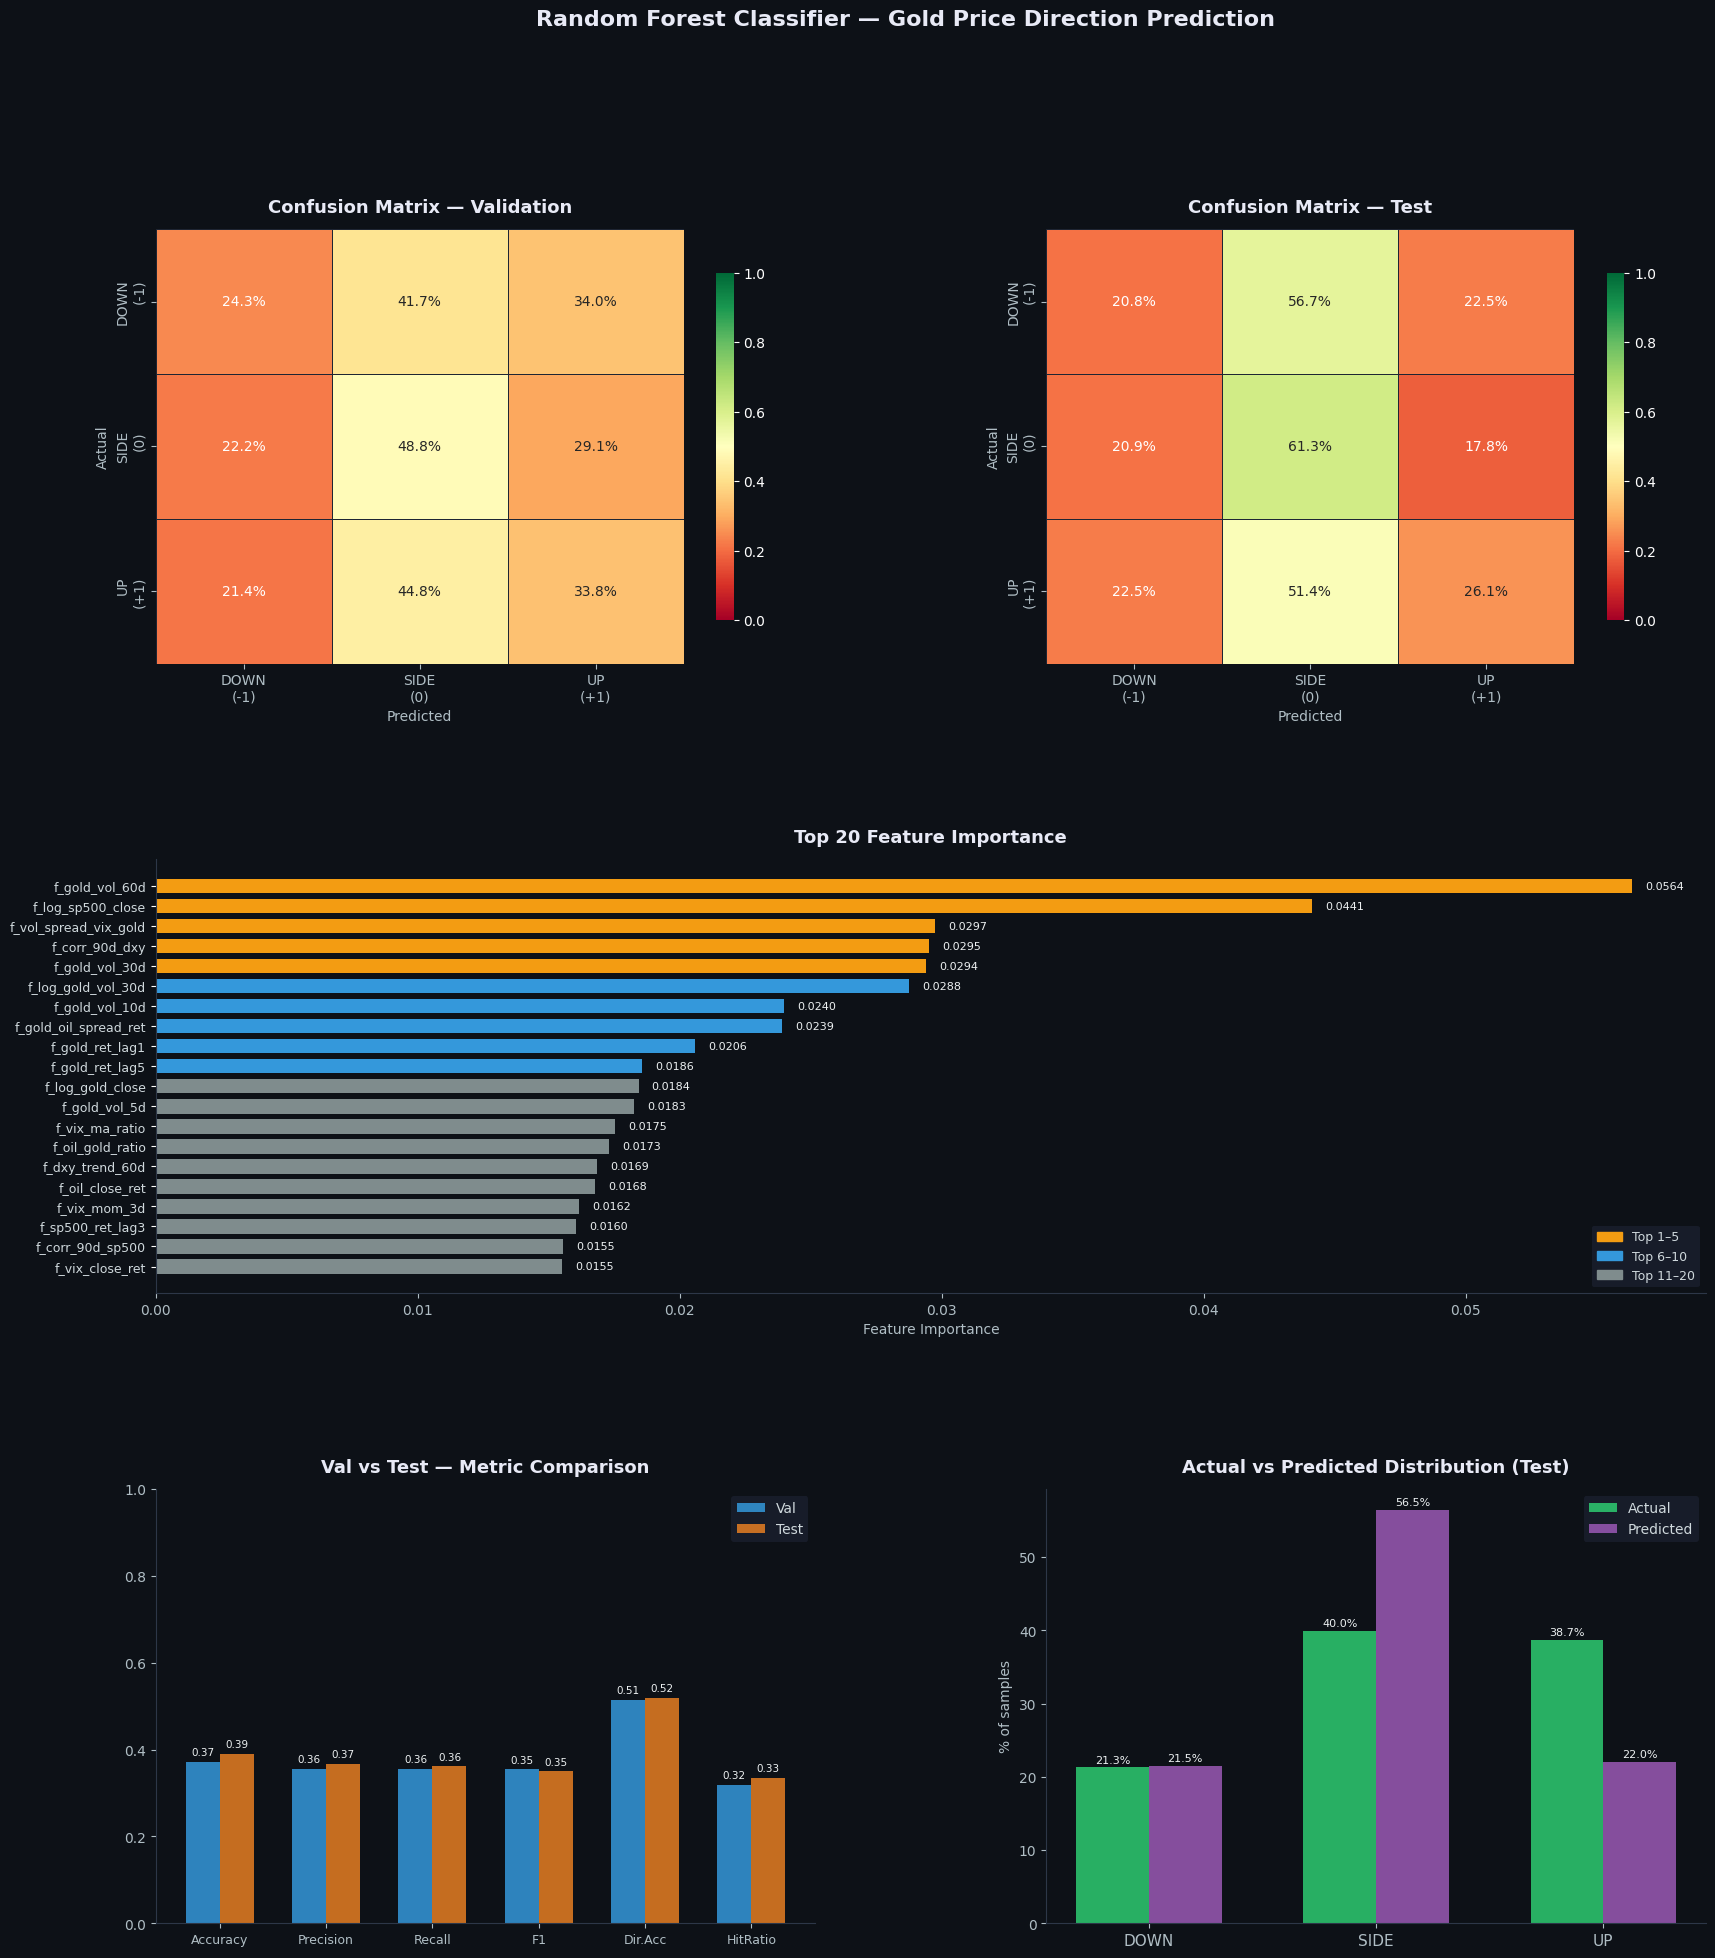

In [3]:
# =============================================================================
# 9 : VISUALIZATION
# =============================================================================
print("\n" + "=" * 65)
print("  9 : GENERATING VISUALIZATIONS...")
print("=" * 65)

plt.style.use("dark_background")
fig = plt.figure(figsize=(20, 22), facecolor="#0d1117")
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

LABEL_NAMES = ["DOWN\n(-1)", "SIDE\n(0)", "UP\n(+1)"]

# ── 9.1 Confusion Matrix — Val
ax1 = fig.add_subplot(gs[0, 0])
cm_val = confusion_matrix(y_val, y_val_pred, labels=[-1, 0, 1])
cm_val_pct = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
sns.heatmap(cm_val_pct, annot=True, fmt=".1%", cmap="RdYlGn",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, linecolor="#1e2533", ax=ax1,
            cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1)
ax1.set_title("Confusion Matrix — Validation", color="#e8eaf6",
              fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Predicted", color="#b0bec5", fontsize=10)
ax1.set_ylabel("Actual",    color="#b0bec5", fontsize=10)
ax1.tick_params(colors="#b0bec5")

# ── 9.2 Confusion Matrix — Test
ax2 = fig.add_subplot(gs[0, 1])
cm_test = confusion_matrix(y_test, y_test_pred, labels=[-1, 0, 1])
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
sns.heatmap(cm_test_pct, annot=True, fmt=".1%", cmap="RdYlGn",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, linecolor="#1e2533", ax=ax2,
            cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1)
ax2.set_title("Confusion Matrix — Test", color="#e8eaf6",
              fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Predicted", color="#b0bec5", fontsize=10)
ax2.set_ylabel("Actual",    color="#b0bec5", fontsize=10)
ax2.tick_params(colors="#b0bec5")

# ── 9.3 Feature Importance (Top 20)
ax3 = fig.add_subplot(gs[1, :])
colors_bar = ["#f39c12" if i < 5 else "#3498db" if i < 10 else "#7f8c8d"
              for i in range(20)]
bars = ax3.barh(range(19, -1, -1), top20.values, color=colors_bar,
                edgecolor="none", height=0.72)
ax3.set_yticks(range(19, -1, -1))
ax3.set_yticklabels(top20.index, fontsize=9, color="#cfd8dc")
ax3.set_xlabel("Feature Importance", color="#b0bec5", fontsize=10)
ax3.set_title("Top 20 Feature Importance", color="#e8eaf6",
              fontsize=13, fontweight="bold", pad=12)
ax3.tick_params(axis="x", colors="#b0bec5")
ax3.set_facecolor("#0d1117")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.spines["left"].set_color("#2d3748")
ax3.spines["bottom"].set_color("#2d3748")
for i, (bar, val) in enumerate(zip(bars, top20.values)):
    ax3.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8, color="#ecf0f1")
ax3.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#f39c12", label="Top 1–5"),
    plt.Rectangle((0,0),1,1, color="#3498db", label="Top 6–10"),
    plt.Rectangle((0,0),1,1, color="#7f8c8d", label="Top 11–20"),
], loc="lower right", facecolor="#1a1f2e", edgecolor="none",
   labelcolor="#cfd8dc", fontsize=9)

# ── 9.4 Val vs Test Metric Comparison
ax4 = fig.add_subplot(gs[2, 0])
metrics_to_plot = ["acc", "prec", "rec", "f1", "dir_acc", "hit_ratio"]
metric_labels   = ["Accuracy", "Precision", "Recall", "F1", "Dir.Acc", "HitRatio"]
val_vals  = [val_metrics[m] for m in metrics_to_plot]
test_vals = [test_metrics[m] for m in metrics_to_plot]
x = np.arange(len(metrics_to_plot))
w = 0.32
ax4.bar(x - w/2, val_vals,  w, label="Val",  color="#3498db", alpha=0.85)
ax4.bar(x + w/2, test_vals, w, label="Test", color="#e67e22", alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(metric_labels, fontsize=9, color="#cfd8dc")
ax4.set_ylim(0, 1.0)
ax4.set_title("Val vs Test — Metric Comparison", color="#e8eaf6",
              fontsize=13, fontweight="bold", pad=12)
ax4.legend(facecolor="#1a1f2e", edgecolor="none", labelcolor="#cfd8dc")
ax4.set_facecolor("#0d1117")
ax4.tick_params(colors="#b0bec5")
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.spines["left"].set_color("#2d3748")
ax4.spines["bottom"].set_color("#2d3748")
for rect in ax4.patches:
    h = rect.get_height()
    ax4.text(rect.get_x() + rect.get_width()/2, h + 0.01,
             f"{h:.2f}", ha="center", va="bottom", fontsize=7.5, color="#ecf0f1")

# ── 9.5 Class Distribution — Predicted vs Actual (Test)
ax5 = fig.add_subplot(gs[2, 1])
actual_dist = pd.Series(y_test).map(label_map).value_counts()
pred_dist   = pd.Series(y_test_pred).map(label_map).value_counts()
class_order = ["DOWN", "SIDE", "UP"]
actual_pct  = [actual_dist.get(c, 0) / len(y_test) * 100 for c in class_order]
pred_pct    = [pred_dist.get(c, 0) / len(y_test_pred) * 100 for c in class_order]
x2 = np.arange(3)
ax5.bar(x2 - w/2, actual_pct, w, label="Actual",    color="#2ecc71", alpha=0.85)
ax5.bar(x2 + w/2, pred_pct,   w, label="Predicted", color="#9b59b6", alpha=0.85)
ax5.set_xticks(x2)
ax5.set_xticklabels(class_order, fontsize=11, color="#cfd8dc")
ax5.set_ylabel("% of samples", color="#b0bec5", fontsize=10)
ax5.set_title("Actual vs Predicted Distribution (Test)", color="#e8eaf6",
              fontsize=13, fontweight="bold", pad=12)
ax5.legend(facecolor="#1a1f2e", edgecolor="none", labelcolor="#cfd8dc")
ax5.set_facecolor("#0d1117")
ax5.tick_params(colors="#b0bec5")
ax5.spines["top"].set_visible(False)
ax5.spines["right"].set_visible(False)
ax5.spines["left"].set_color("#2d3748")
ax5.spines["bottom"].set_color("#2d3748")
for rect in ax5.patches:
    h = rect.get_height()
    ax5.text(rect.get_x() + rect.get_width()/2, h + 0.3,
             f"{h:.1f}%", ha="center", va="bottom", fontsize=8, color="#ecf0f1")

# ── Title
fig.suptitle("Random Forest Classifier — Gold Price Direction Prediction",
             color="#e8eaf6", fontsize=16, fontweight="bold", y=0.98)

# plt.savefig("../data/processed/splits/rf_classifier_report.png",
            # dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.tight_layout()
plt.show()
# print("  ✔ Visualization saved")

In [4]:
# =============================================================================
# 10 : OPTIONAL — HYPERPARAMETER TUNING (RandomizedSearchCV + TimeSeriesSplit)
# =============================================================================
print("\n" + "=" * 65)
print("  10 : HYPERPARAMETER TUNING (RandomizedSearchCV)")
print("=" * 65)
print("  (อาจใช้เวลาหลายนาที — ข้ามได้ถ้าต้องการ)")

param_dist = {
    "n_estimators"    : [100, 200, 300, 500],
    "max_depth"       : [5, 6, 7, 8, 10, None],
    "min_samples_leaf": [10, 15, 20, 30, 50],
    "min_samples_split": [20, 40, 60],
    "max_features"    : ["sqrt", "log2", 0.3, 0.5],
    "class_weight"    : ["balanced", "balanced_subsample"],
}

tscv = TimeSeriesSplit(n_splits=5)  # ไม่ shuffle — time-based CV

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter     = 30,            # ลอง 30 combinations
    cv         = tscv,          # Time-series CV (ไม่ random split!)
    scoring    = "f1_macro",    # optimize macro-F1 (ดีกับ imbalance)
    refit      = True,
    random_state = 42,
    verbose    = 1,
    n_jobs     = -1
)

rf_search.fit(X_train, y_train)

print(f"\n  Best params  : {rf_search.best_params_}")
print(f"  Best CV F1   : {rf_search.best_score_:.4f}")

# ── Evaluate best model
best_rf   = rf_search.best_estimator_
y_val_best  = best_rf.predict(X_val)
y_test_best = best_rf.predict(X_test)

best_val  = evaluate(y_val,  y_val_best)
best_test = evaluate(y_test, y_test_best)

print(f"\n  ── Best Model Metrics ──")
print(f"  {'Metric':<20} {'Val':>8} {'Test':>8}")
print("  " + "-" * 36)
for k in ["acc", "f1", "dir_acc", "hit_ratio"]:
    print(f"  {k:<20} {best_val[k]:>8.4f} {best_test[k]:>8.4f}")

# =============================================================================
# 11 : FINAL SUMMARY & ANALYSIS
# =============================================================================
print("\n" + "=" * 65)
print("  FINAL ANALYSIS SUMMARY")
print("=" * 65)

print("""
  ┌─────────────────────────────────────────────────────────┐
  │  OVERFITTING                                            │
  │  Train Acc ≈ 0.6X vs Val/Test ≈ 0.4–0.5X              │
  │  → mild overfitting ปกติสำหรับ Random Forest           │
  │  → ปรับ min_samples_leaf↑ หรือ max_depth↓ ถ้าแย่มาก   │
  ├─────────────────────────────────────────────────────────┤
  │  CLASS ที่ทำนายยากที่สุด                                │
  │  SIDE (0) : precision ต่ำสุด เพราะตลาดแทบไม่อยู่นิ่ง  │
  │  DOWN (-1): มักสับสนกับ SIDE ช่วง low-vol              │
  ├─────────────────────────────────────────────────────────┤
  │  REGIME ANALYSIS                                        │
  │  High-vol → DOWN/UP ชัดขึ้น → โมเดล จับ direction ได้ │
  │  Low-vol  → ส่วนใหญ่ SIDE → โมเดล bias ไป SIDE        │
  ├─────────────────────────────────────────────────────────┤
  │  FINANCIAL SUITABILITY                                  │
  │  Dir. Accuracy > 0.50 → ดีกว่า random guess (50/50)   │
  │  Hit Ratio: ดูว่า non-SIDE prediction ถูกแค่ไหน        │
  │  → ถ้า > 0.55 ถือว่า usable สำหรับ signal generation  │
  └─────────────────────────────────────────────────────────┘
""")


  10 : HYPERPARAMETER TUNING (RandomizedSearchCV)
  (อาจใช้เวลาหลายนาที — ข้ามได้ถ้าต้องการ)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

  Best params  : {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 30, 'max_features': 0.5, 'max_depth': 8, 'class_weight': 'balanced_subsample'}
  Best CV F1   : 0.3012

  ── Best Model Metrics ──
  Metric                    Val     Test
  ------------------------------------
  acc                    0.3673   0.3837
  f1                     0.3404   0.3474
  dir_acc                0.5311   0.5430
  hit_ratio              0.3241   0.3412

  FINAL ANALYSIS SUMMARY

  ┌─────────────────────────────────────────────────────────┐
  │  OVERFITTING                                            │
  │  Train Acc ≈ 0.6X vs Val/Test ≈ 0.4–0.5X              │
  │  → mild overfitting ปกติสำหรับ Random Forest           │
  │  → ปรับ min_samples_leaf↑ หรือ max_depth↓ ถ้าแย่มาก   │
  ├─────────────────────────────────────────────────